In [172]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

pd.set_option('display.notebook_repr_html', True)

def create_seaborn_boxplot(data, x, y, ax, title, ylabel, xlabel, scale_range=None):
    colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494', '#b3b3b3']
    unique_vals = sorted(data[x].unique())
    palette = colors[:len(unique_vals)]
    
    sns.boxplot(data=data, x=x, y=y, ax=ax, palette=palette,
                medianprops={'color': 'black', 'linewidth': 2.5, 'linestyle': ':'})
    
    for i, val in enumerate(unique_vals):
        mean_val = data[data[x] == val][y].mean()
        ax.scatter(i, mean_val, color='red', marker='D', s=50, zorder=3, 
                  edgecolor='darkred', linewidth=1)
    
    label_mapping = {
        'anthropic': 'Anthropic',
        'openai': 'OpenAI', 
        'google': 'Google',
        'deepseek': 'DeepSeek',
        'common': 'Common',
        'complex': 'Complex',
        'script': 'Script',
        'transcript': 'Transcript', 
        'tanenbaum': 'Tanenbaum',
        'script_manipulated': 'Script (Manipulated)',
        'exp1a': 'Exp 1a',
        'exp1b': 'Exp 1b'
    }
    
    current_labels = [tick.get_text() for tick in ax.get_xticklabels()]
    new_labels = [label_mapping.get(label, label) for label in current_labels]
    ax.set_xticklabels(new_labels, rotation=0)
    
    if scale_range:
        ax.set_ylim(scale_range)
        if scale_range == (0, 10):
            title += " (0-10 scale)"
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11, labelpad=15)
    ax.set_xlabel(xlabel, fontsize=11, labelpad=10)
    ax.grid(True, alpha=0.3)

BASE_PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

expert_base_path = os.path.join(BASE_PROJECT_PATH, "20_experiments/60_analyses/csv_files/qualitative")
hint_base_path = os.path.join(expert_base_path, "hint_csvs_exp1")

output_base_path = os.path.join(BASE_PROJECT_PATH, "40_evaluation/exp1/qualitative")
output_tables_path = os.path.join(output_base_path, "tables")
output_plots_path = os.path.join(output_base_path, "plots")

for path in [output_tables_path, output_plots_path]:
    os.makedirs(path, exist_ok=True)

tables = {}
plots = {}

print(f"✓ Setup completed")
print(f"✓ Output tables: {output_tables_path}")
print(f"✓ Output plots: {output_plots_path}")

✓ Setup completed
✓ Output tables: /home/malde/git/bachelor-thesis/40_evaluation/exp1/qualitative/tables
✓ Output plots: /home/malde/git/bachelor-thesis/40_evaluation/exp1/qualitative/plots


## Data Loading and Preprocessing

In [173]:
def load_and_prepare_data():
    
    hint_exp1a = pd.read_csv(os.path.join(hint_base_path, "exp1a.csv"))
    hint_exp1b = pd.read_csv(os.path.join(hint_base_path, "exp1b.csv"))
    
    expert1_exp1a = pd.read_csv(os.path.join(expert_base_path, "expert_1", "exp1a.csv"))
    expert1_exp1b = pd.read_csv(os.path.join(expert_base_path, "expert_1", "exp1b.csv"))
    
    exp1a_df = pd.concat([expert1_exp1a, hint_exp1a[['llm', 'prompt_type']]], axis=1)
    exp1b_df = pd.concat([expert1_exp1b, hint_exp1b[['llm', 'prompt_type']]], axis=1)
    
    numeric_cols_1a = ['relevance', 'clarity', 'answerability', 'challenging', 'value', 'language', 'correctness']
    numeric_cols_1b = ['relevance', 'clarity', 'answerability', 'challenging', 'value', 'language', 'manipulation_handling']
    
    for col in numeric_cols_1a:
        if col in exp1a_df.columns:
            exp1a_df[col] = exp1a_df[col].replace(['??', '???', ''], np.nan)
            exp1a_df[col] = pd.to_numeric(exp1a_df[col], errors='coerce')
    
    for col in numeric_cols_1b:
        if col in exp1b_df.columns:
            exp1b_df[col] = exp1b_df[col].replace(['??', '???', ''], np.nan)
            exp1b_df[col] = pd.to_numeric(exp1b_df[col], errors='coerce')
    
    exp1a_df['experiment'] = 'exp1a'
    exp1b_df['experiment'] = 'exp1b'
    
    exp1b_df['input_source'] = exp1b_df['input_source'].replace('script', 'script_manipulated')
    
    print(f"✓ Loaded Experiment 1a: {len(exp1a_df)} samples")
    print(f"✓ Loaded Experiment 1b: {len(exp1b_df)} samples")
    
    exp1a_df['total_score'] = exp1a_df[numeric_cols_1a].sum(axis=1)
    exp1b_df['total_score'] = exp1b_df[numeric_cols_1b].sum(axis=1)
    
    filled_1a = exp1a_df[numeric_cols_1a].notna().sum().sum()
    total_1a = len(exp1a_df) * len(numeric_cols_1a)
    print(f"✓ Exp 1a completion: {filled_1a}/{total_1a} ({100*filled_1a/total_1a:.1f}%)")
    
    filled_1b = exp1b_df[numeric_cols_1b].notna().sum().sum()
    total_1b = len(exp1b_df) * len(numeric_cols_1b)
    print(f"✓ Exp 1b completion: {filled_1b}/{total_1b} ({100*filled_1b/total_1b:.1f}%)")
    
    return exp1a_df, exp1b_df, numeric_cols_1a, numeric_cols_1b

exp1a_df, exp1b_df, numeric_cols_1a, numeric_cols_1b = load_and_prepare_data()

print("\n" + "="*50)
print("DATA OVERVIEW")
print("="*50)

print(f"\nExperiment 1a Distribution:")
print(f"  LLMs: {dict(exp1a_df['llm'].value_counts())}")
print(f"  Prompt Types: {dict(exp1a_df['prompt_type'].value_counts())}")
print(f"  Input Sources: {dict(exp1a_df['input_source'].value_counts())}")

print(f"\nExperiment 1b Distribution:")
print(f"  LLMs: {dict(exp1b_df['llm'].value_counts())}")
print(f"  Prompt Types: {dict(exp1b_df['prompt_type'].value_counts())}")
print(f"  Input Sources: {dict(exp1b_df['input_source'].value_counts())}")

✓ Loaded Experiment 1a: 48 samples
✓ Loaded Experiment 1b: 16 samples
✓ Exp 1a completion: 323/336 (96.1%)
✓ Exp 1b completion: 0/112 (0.0%)

DATA OVERVIEW

Experiment 1a Distribution:
  LLMs: {'anthropic': np.int64(12), 'deepseek': np.int64(12), 'google': np.int64(12), 'openai': np.int64(12)}
  Prompt Types: {'common': np.int64(24), 'complex': np.int64(24)}
  Input Sources: {'script': np.int64(16), 'tanenbaum': np.int64(16), 'transcript': np.int64(16)}

Experiment 1b Distribution:
  LLMs: {'anthropic': np.int64(4), 'deepseek': np.int64(4), 'google': np.int64(4), 'openai': np.int64(4)}
  Prompt Types: {'common': np.int64(8), 'complex': np.int64(8)}
  Input Sources: {'script_manipulated': np.int64(16)}


# Experiment 1a: Original Content Analysis

Analysis of LLM question generation quality using original source materials (script, transcript, tanenbaum textbook).

## 1a.1: Descriptive Statistics

In [174]:
print("EXPERIMENT 1A - DESCRIPTIVE STATISTICS")
print("="*60)

exp1a_stats = exp1a_df[numeric_cols_1a].describe().round(2)
tables['exp1a_overall_stats'] = exp1a_stats
print("\nOverall Statistics (all criteria):")
display(exp1a_stats)

exp1a_llm_stats = exp1a_df.groupby('llm')[numeric_cols_1a].agg(['mean', 'std', 'count']).round(2)
tables['exp1a_llm_stats'] = exp1a_llm_stats
print("\nStatistics by LLM:")
display(exp1a_llm_stats)

exp1a_source_stats = exp1a_df.groupby('input_source')[numeric_cols_1a].agg(['mean', 'std', 'count']).round(2)
tables['exp1a_source_stats'] = exp1a_source_stats
print("\nStatistics by Input Source:")
display(exp1a_source_stats)

exp1a_prompt_stats = exp1a_df.groupby('prompt_type')[numeric_cols_1a].agg(['mean', 'std', 'count']).round(2)
tables['exp1a_prompt_stats'] = exp1a_prompt_stats
print("\nStatistics by Prompt Type:")
display(exp1a_prompt_stats)

EXPERIMENT 1A - DESCRIPTIVE STATISTICS

Overall Statistics (all criteria):


,relevance,clarity,answerability,challenging,value,language,correctness
count,47.00,47.00,47.00,47.00,45.00,48.00,42.00
mean,9.32,8.68,8.21,4.64,7.47,8.98,8.57
std,2.05,2.61,2.93,3.57,3.75,2.07,2.98
min,2.00,2.00,0.00,0.00,0.00,3.00,0.00
25%,10.00,10.00,6.00,2.00,4.00,10.00,10.00
50%,10.00,10.00,10.00,4.00,10.00,10.00,10.00
75%,10.00,10.00,10.00,8.00,10.00,10.00,10.00
max,10.00,10.00,10.00,10.00,10.00,10.00,10.00



Statistics by LLM:


relevance             clarity             answerability              \
               mean   std count    mean   std count          mean   std count   
llm                                                                             
anthropic      9.00  2.34    12    7.33  3.45    12          7.50  2.84    12   
deepseek       8.67  3.11    12    9.67  1.15    12          8.50  2.84    12   
google         9.64  1.21    11    7.64  3.20    11          7.45  3.59    11   
openai        10.00  0.00    12   10.00  0.00    12          9.33  2.31    12   

          challenging              value             language              \
                 mean   std count   mean   std count     mean   std count   
llm                                                                         
anthropic        6.67  2.99    12   7.00  3.67    12     8.25  2.42    12   
deepseek         3.50  4.01    12   6.00  4.42    10    10.00  0.00    12   
google           5.27  3.82    11   6.55  4.30    11     7.67  2.77    12   
openai           3.17  2.48    12  10.00  0.00    12    10.00  0.00    12   

          correctness              
                 mean   std count  
llm                                
anthropic        8.50  2.42    10  
deepseek         8.64  2.34    11  
google           6.67  5.00     9  
openai          10.00  0.00    12


Statistics by Input Source:


relevance             clarity             answerability        \
                  mean   std count    mean   std count          mean   std   
input_source                                                                 
script            9.38  2.03    16    8.50  2.37    16          8.25  2.52   
tanenbaum         9.12  2.19    16    8.25  3.26    16          7.12  3.79   
transcript        9.47  2.07    15    9.33  2.09    15          9.33  1.80   

                   challenging             value             language        \
             count        mean   std count  mean   std count     mean   std   
input_source                                                                  
script          16        5.50  3.54    16  7.38  3.32    16     8.88  2.19   
tanenbaum       16        5.38  4.05    16  7.14  4.05    14     8.88  2.19   
transcript      15        2.93  2.49    15  7.87  4.10    15     9.19  1.94   

                   correctness              
             count        mean   std count  
input_source                                
script          16        7.67  3.72    15  
tanenbaum       16        8.33  3.26    12  
transcript      16        9.67  1.29    15


Statistics by Prompt Type:


relevance             clarity             answerability        \
                 mean   std count    mean   std count          mean   std   
prompt_type                                                                 
common          10.00  0.00    24    10.0  0.00    24          9.92  0.41   
complex          8.61  2.79    23     7.3  3.23    23          6.43  3.36   

                  challenging             value             language        \
            count        mean   std count  mean   std count     mean   std   
prompt_type                                                                  
common         24        2.50  1.69    24  9.55  2.13    22    10.00  0.00   
complex        23        6.87  3.66    23  5.48  3.92    23     7.96  2.56   

                  correctness              
            count        mean   std count  
prompt_type                                
common         24        9.35  2.29    23  
complex        24        7.63  3.48    19

## 1a.2: Analysis by LLM

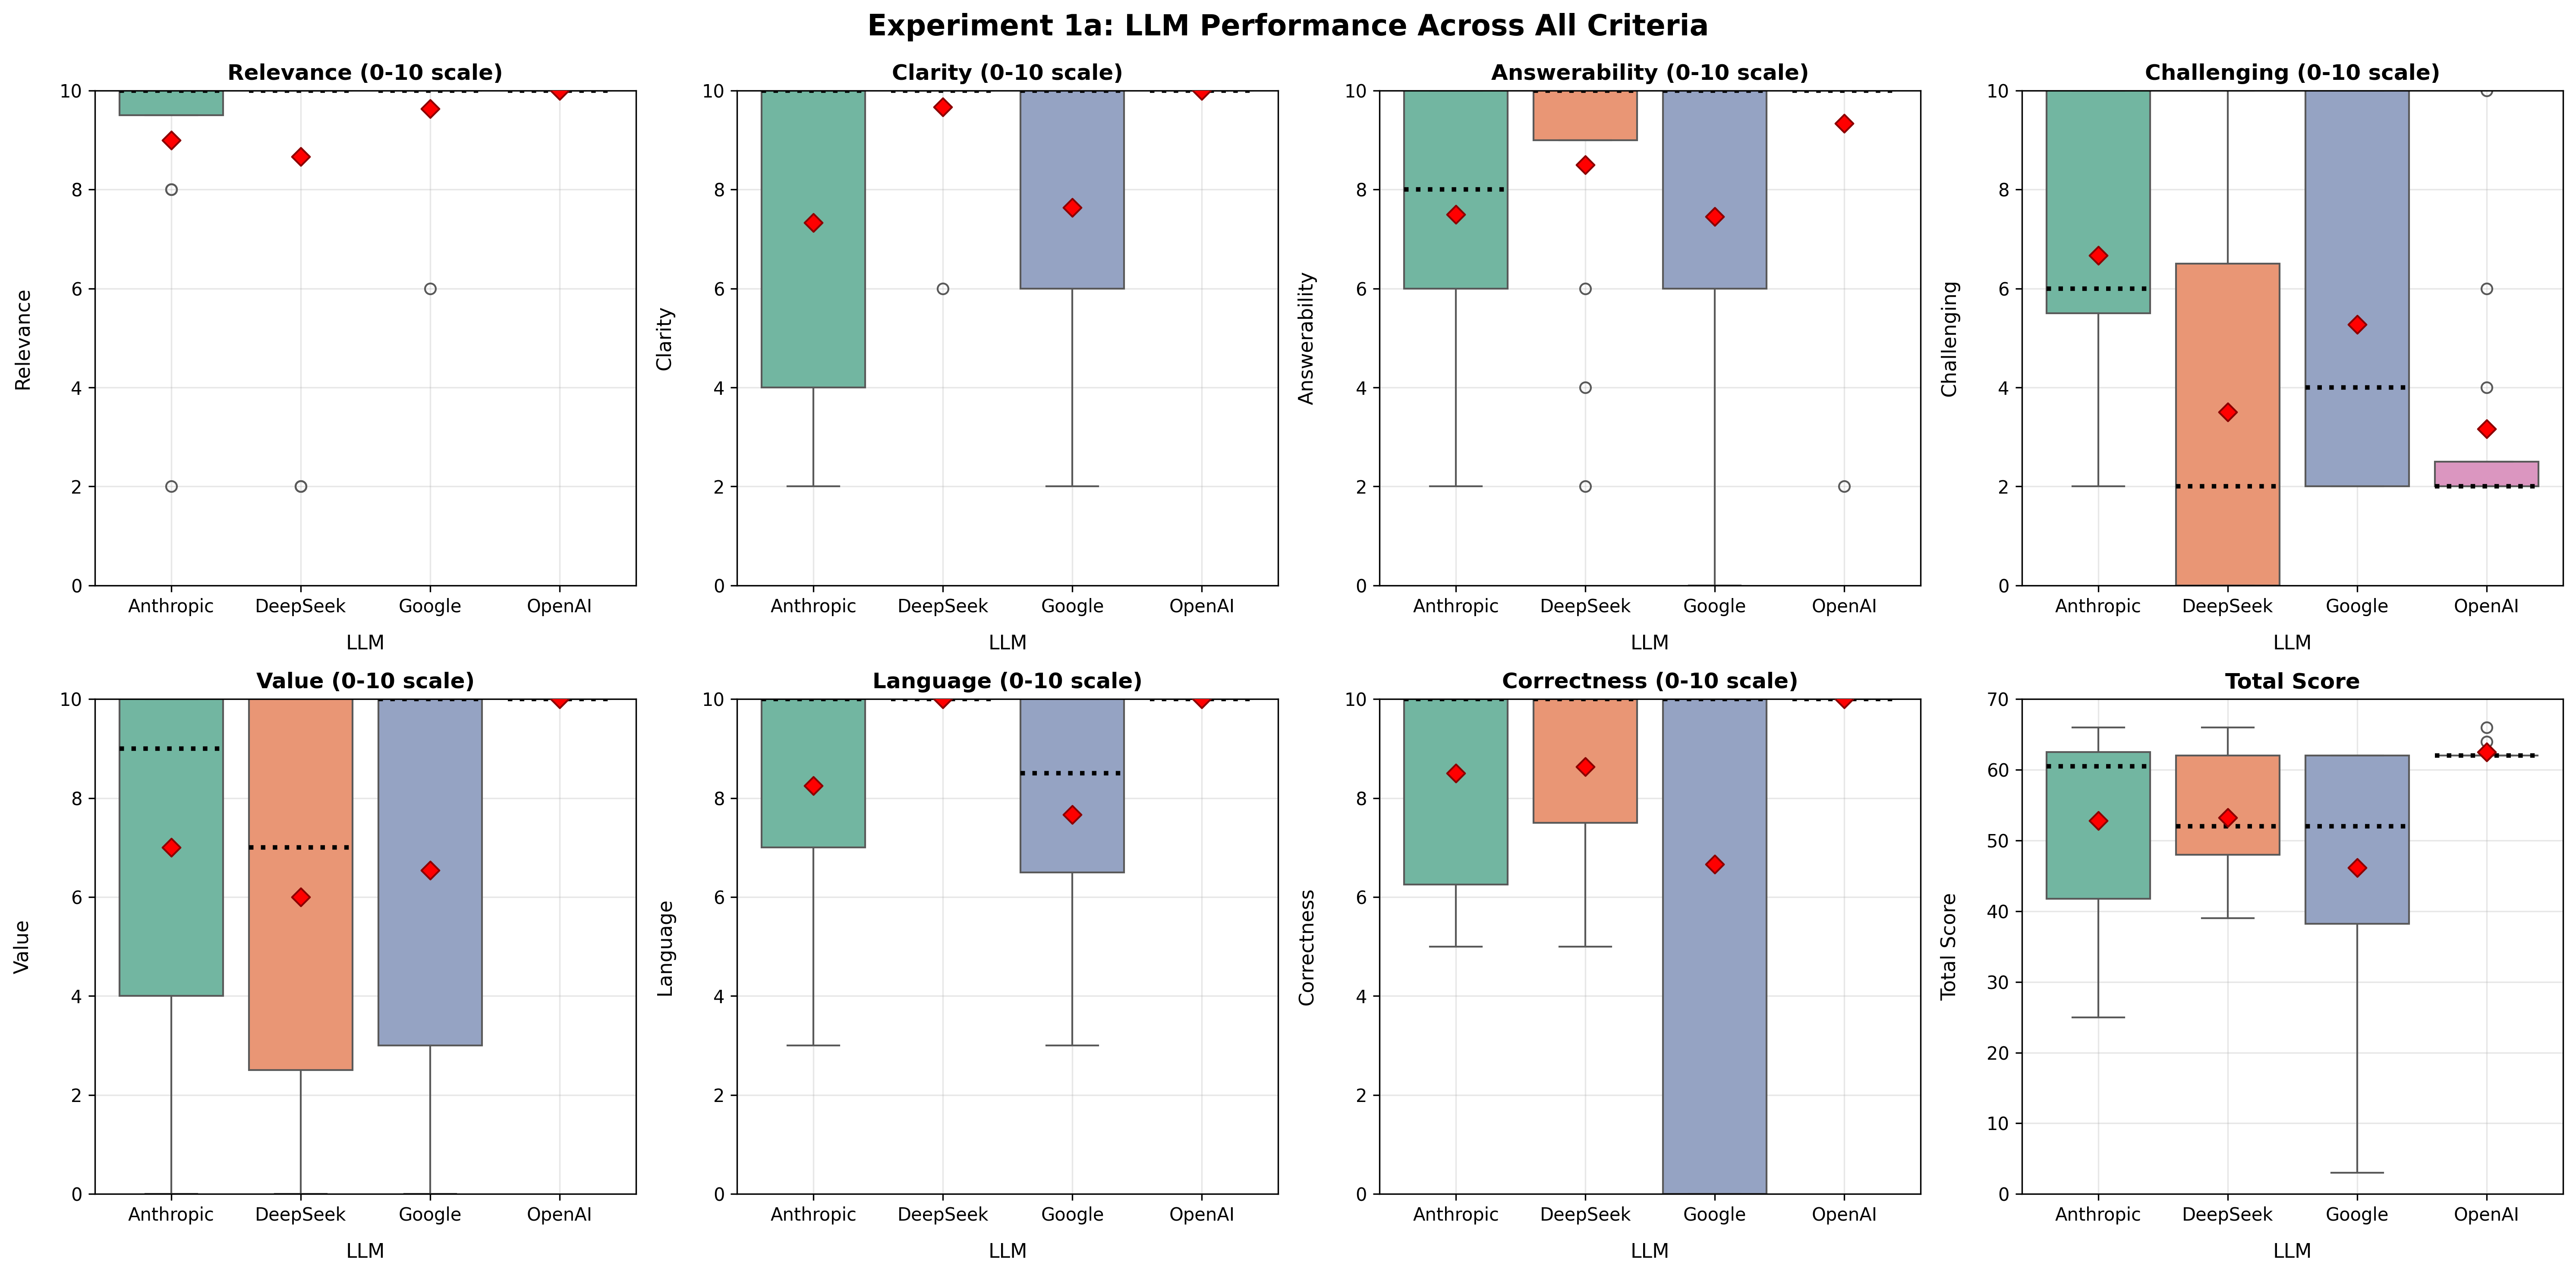


DETAILED STATISTICS - LLM PERFORMANCE (EXPERIMENT 1A)

Detailed Statistics by LLM (Experiment 1a):


relevance                                clarity                     \
               mean   std median   min   max count    mean   std median   min   
llm                                                                             
anthropic      9.00  2.34   10.0   2.0  10.0    12    7.33  3.45   10.0   2.0   
deepseek       8.67  3.11   10.0   2.0  10.0    12    9.67  1.15   10.0   6.0   
google         9.64  1.21   10.0   6.0  10.0    11    7.64  3.20   10.0   2.0   
openai        10.00  0.00   10.0  10.0  10.0    12   10.00  0.00   10.0  10.0   

                      answerability                               challenging  \
            max count          mean   std median  min   max count        mean   
llm                                                                             
anthropic  10.0    12          7.50  2.84    8.0  2.0  10.0    12        6.67   
deepseek   10.0    12          8.50  2.84   10.0  2.0  10.0    12        3.50   
google     10.0    11          7.45  3.59   10.0  0.0  10.0    11        5.27   
openai     10.0    12          9.33  2.31   10.0  2.0  10.0    12        3.17   

                                         value                                 \
            std median  min   max count   mean   std median   min   max count   
llm                                                                             
anthropic  2.99    6.0  2.0  10.0    12   7.00  3.67    9.0   0.0  10.0    12   
deepseek   4.01    2.0  0.0  10.0    12   6.00  4.42    7.0   0.0  10.0    10   
google     3.82    4.0  2.0  10.0    11   6.55  4.30   10.0   0.0  10.0    11   
openai     2.48    2.0  2.0  10.0    12  10.00  0.00   10.0  10.0  10.0    12   

          language                            correctness                     \
              mean   std median min max count        mean   std median   min   
llm                                                                            
anthropic     8.25  2.42   10.0   3  10    12        8.50  2.42   10.0   5.0   
deepseek     10.00  0.00   10.0  10  10    12        8.64  2.34   10.0   5.0   
google        7.67  2.77    8.5   3  10    12        6.67  5.00   10.0   0.0   
openai       10.00  0.00   10.0  10  10    12       10.00  0.00   10.0  10.0   

                      total_score                                  
            max count        mean    std median   min   max count  
llm                                                                
anthropic  10.0    10       52.83  13.63   60.5  25.0  66.0    12  
deepseek   10.0    11       53.25   9.57   52.0  39.0  66.0    12  
google     10.0     9       46.17  19.37   52.0   3.0  62.0    12  
openai     10.0    12       62.50   1.24   62.0  62.0  66.0    12


Mean Scores by LLM (Experiment 1a):


,relevance,clarity,answerability,challenging,value,language,correctness
llm,,,,,,,
anthropic,9.00,7.33,7.50,6.67,7.00,8.25,8.50
deepseek,8.67,9.67,8.50,3.50,6.00,10.00,8.64
google,9.64,7.64,7.45,5.27,6.55,7.67,6.67
openai,10.00,10.00,9.33,3.17,10.00,10.00,10.00



Overall LLM Ranking (Experiment 1a):
1. Openai: 8.93
2. Deepseek: 7.85
3. Anthropic: 7.75
4. Google: 7.27


In [175]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
plots['exp1a_llm_analysis'] = fig

criteria = ['relevance', 'clarity', 'answerability', 'challenging', 'value', 'language', 'correctness']

for i, criterion in enumerate(criteria):
    create_seaborn_boxplot(exp1a_df, 'llm', criterion, axes[i], 
                          f'{criterion.title()}', criterion.title(), 'LLM', scale_range=(0, 10))

create_seaborn_boxplot(exp1a_df, 'llm', 'total_score', axes[7], 
                      'Total Score', 'Total Score', 'LLM', scale_range=(0, 70))

plt.suptitle('Experiment 1a: LLM Performance Across All Criteria', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

print("\n" + "="*80)
print("DETAILED STATISTICS - LLM PERFORMANCE (EXPERIMENT 1A)")
print("="*80)

all_criteria_with_total = criteria + ['total_score']
exp1a_llm_detailed_stats = exp1a_df.groupby('llm')[all_criteria_with_total].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables['exp1a_llm_detailed_stats'] = exp1a_llm_detailed_stats
print("\nDetailed Statistics by LLM (Experiment 1a):")
display(exp1a_llm_detailed_stats)

exp1a_llm_means = exp1a_df.groupby('llm')[numeric_cols_1a].mean().round(2)
tables['exp1a_llm_means'] = exp1a_llm_means
print("\nMean Scores by LLM (Experiment 1a):")
display(exp1a_llm_means)

exp1a_llm_overall = exp1a_llm_means.mean(axis=1).sort_values(ascending=False)
tables['exp1a_llm_ranking'] = exp1a_llm_overall
print("\nOverall LLM Ranking (Experiment 1a):")
for i, (llm, score) in enumerate(exp1a_llm_overall.items(), 1):
    print(f"{i}. {llm.title()}: {score:.2f}")

## 1a.3: Analysis by Input Source

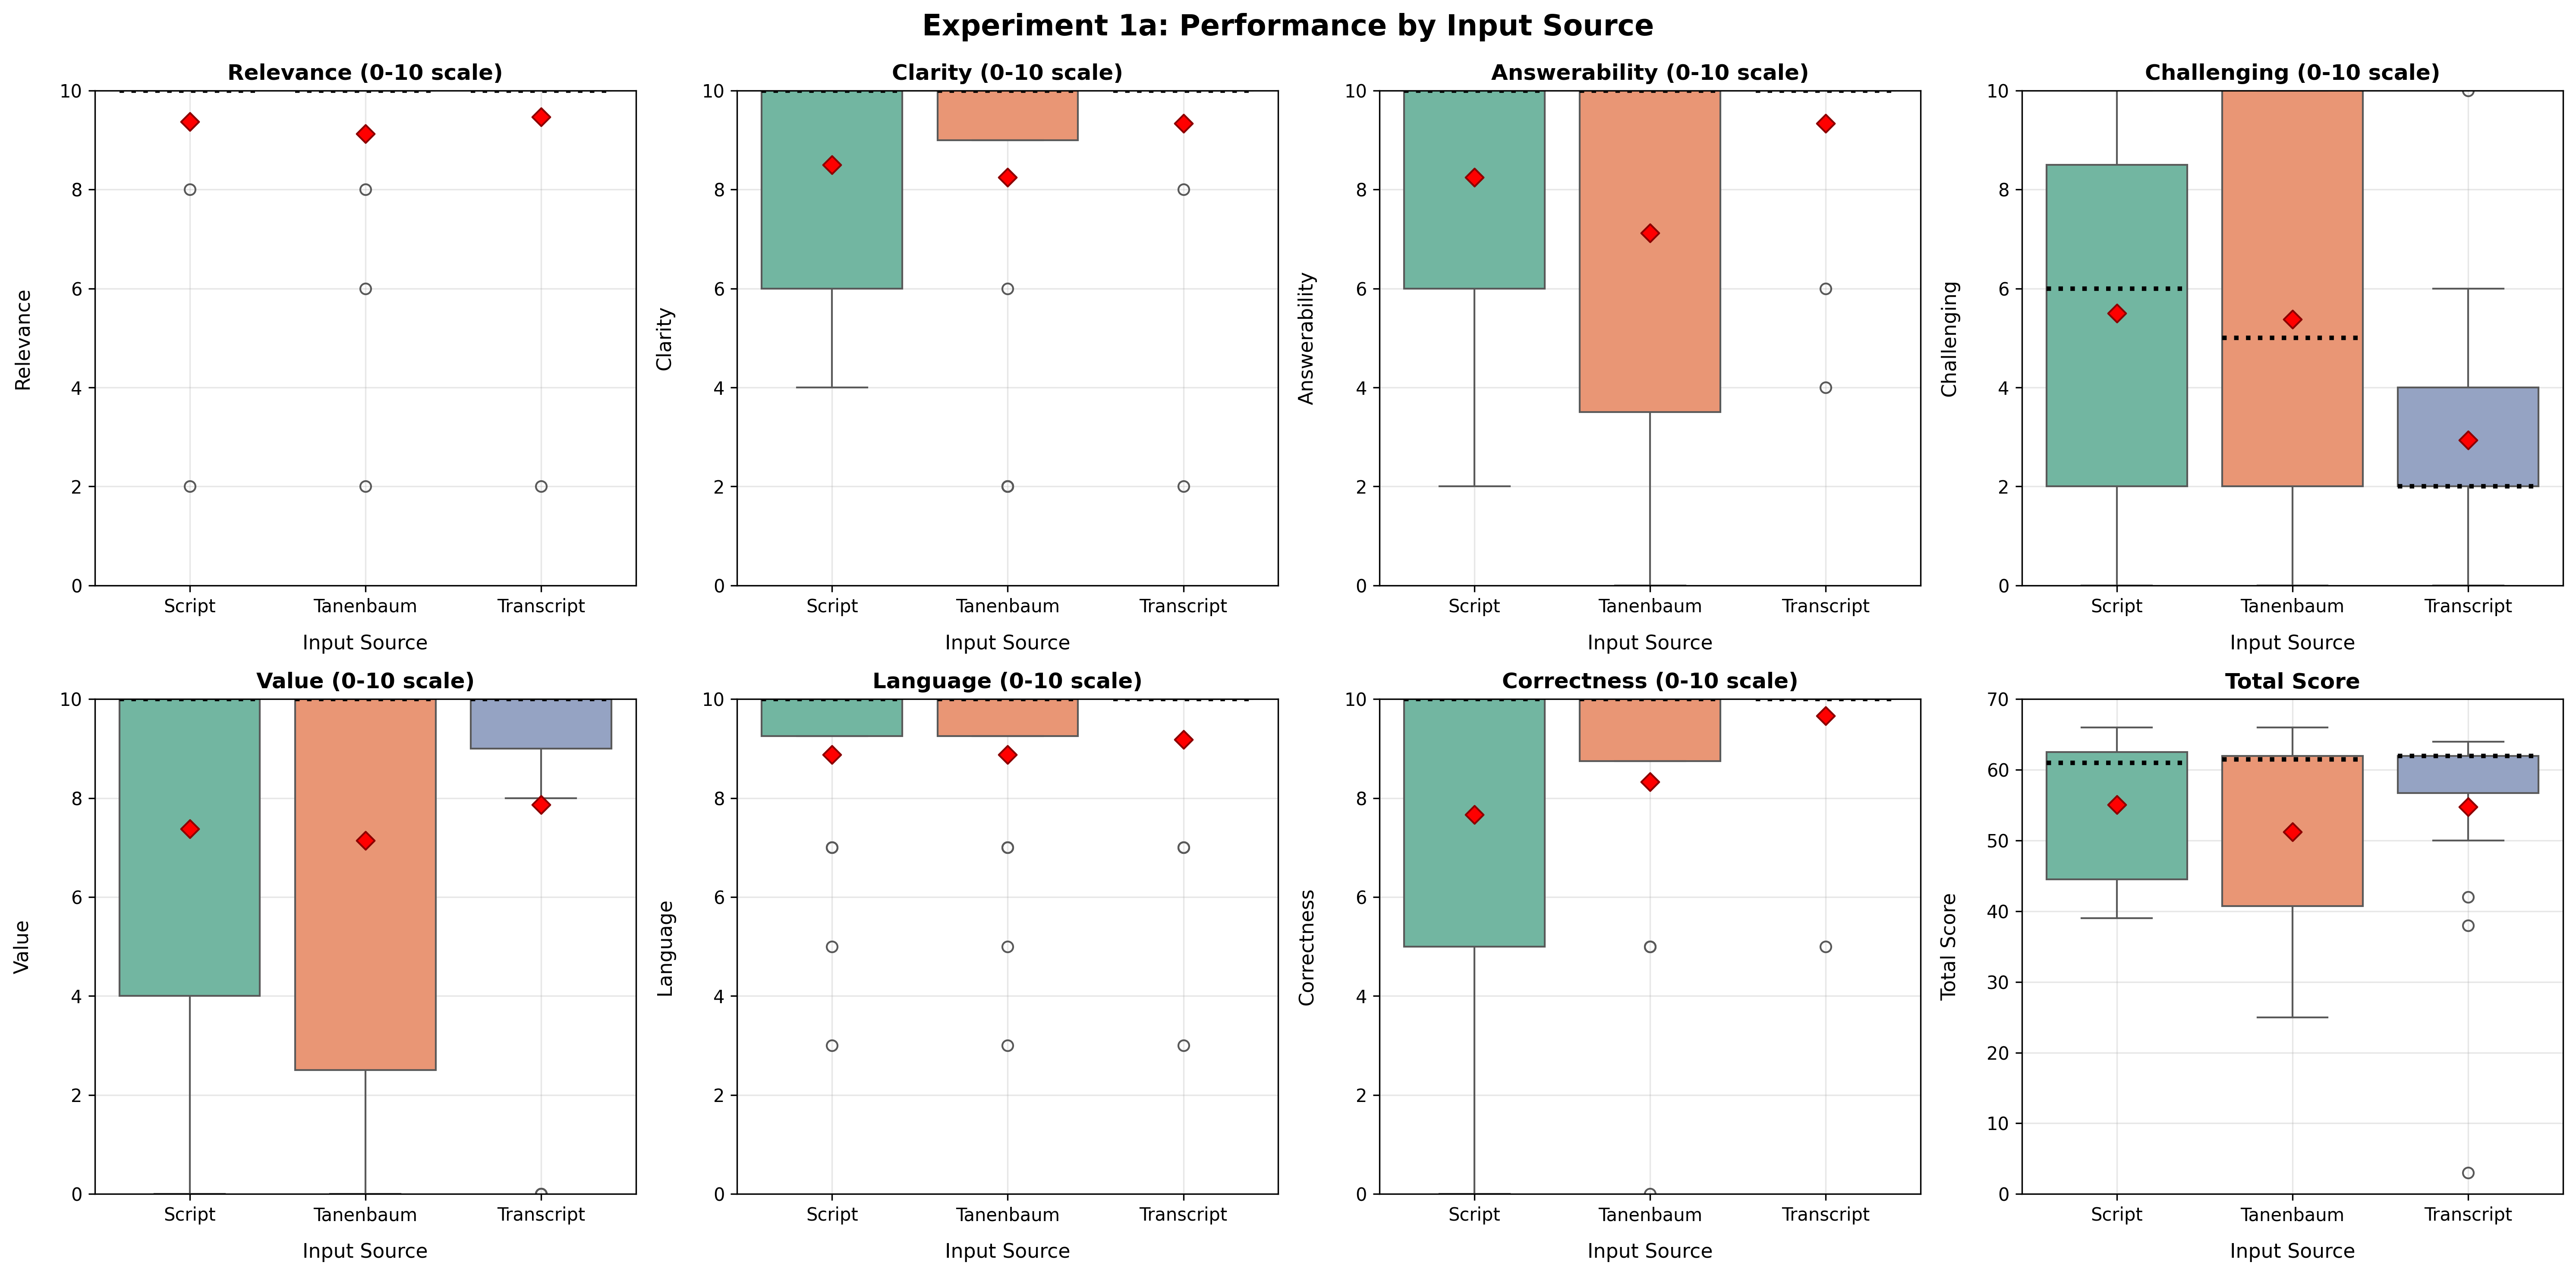


DETAILED STATISTICS - INPUT SOURCE PERFORMANCE (EXPERIMENT 1A)

Detailed Statistics by Input Source (Experiment 1a):


relevance                               clarity               \
                  mean   std median  min   max count    mean   std median   
input_source                                                                
script            9.38  2.03   10.0  2.0  10.0    16    8.50  2.37   10.0   
tanenbaum         9.12  2.19   10.0  2.0  10.0    16    8.25  3.26   10.0   
transcript        9.47  2.07   10.0  2.0  10.0    15    9.33  2.09   10.0   

                              answerability                                \
              min   max count          mean   std median  min   max count   
input_source                                                                
script        4.0  10.0    16          8.25  2.52   10.0  2.0  10.0    16   
tanenbaum     2.0  10.0    16          7.12  3.79   10.0  0.0  10.0    16   
transcript    2.0  10.0    15          9.33  1.80   10.0  4.0  10.0    15   

             challenging                               value               \
                    mean   std median  min   max count  mean   std median   
input_source                                                                
script              5.50  3.54    6.0  0.0  10.0    16  7.38  3.32   10.0   
tanenbaum           5.38  4.05    5.0  0.0  10.0    16  7.14  4.05   10.0   
transcript          2.93  2.49    2.0  0.0  10.0    15  7.87  4.10   10.0   

                              language                            correctness  \
              min   max count     mean   std median min max count        mean   
input_source                                                                    
script        0.0  10.0    16     8.88  2.19   10.0   3  10    16        7.67   
tanenbaum     0.0  10.0    14     8.88  2.19   10.0   3  10    16        8.33   
transcript    0.0  10.0    15     9.19  1.94   10.0   3  10    16        9.67   

                                           total_score                      \
               std median  min   max count        mean    std median   min   
input_source                                                                 
script        3.72   10.0  0.0  10.0    15       55.06  10.23   61.0  39.0   
tanenbaum     3.26   10.0  0.0  10.0    12       51.25  14.88   61.5  25.0   
transcript    1.29   10.0  5.0  10.0    15       54.75  15.88   62.0   3.0   

                          
               max count  
input_source              
script        66.0    16  
tanenbaum     66.0    16  
transcript    64.0    16


Mean Scores by Input Source (Experiment 1a):


,relevance,clarity,answerability,challenging,value,language,correctness
input_source,,,,,,,
script,9.38,8.50,8.25,5.50,7.38,8.88,7.67
tanenbaum,9.12,8.25,7.12,5.38,7.14,8.88,8.33
transcript,9.47,9.33,9.33,2.93,7.87,9.19,9.67



Input Source Ranking by Total Score (Experiment 1a):
1. Script: 55.06/70
2. Transcript: 54.75/70
3. Tanenbaum: 51.25/70


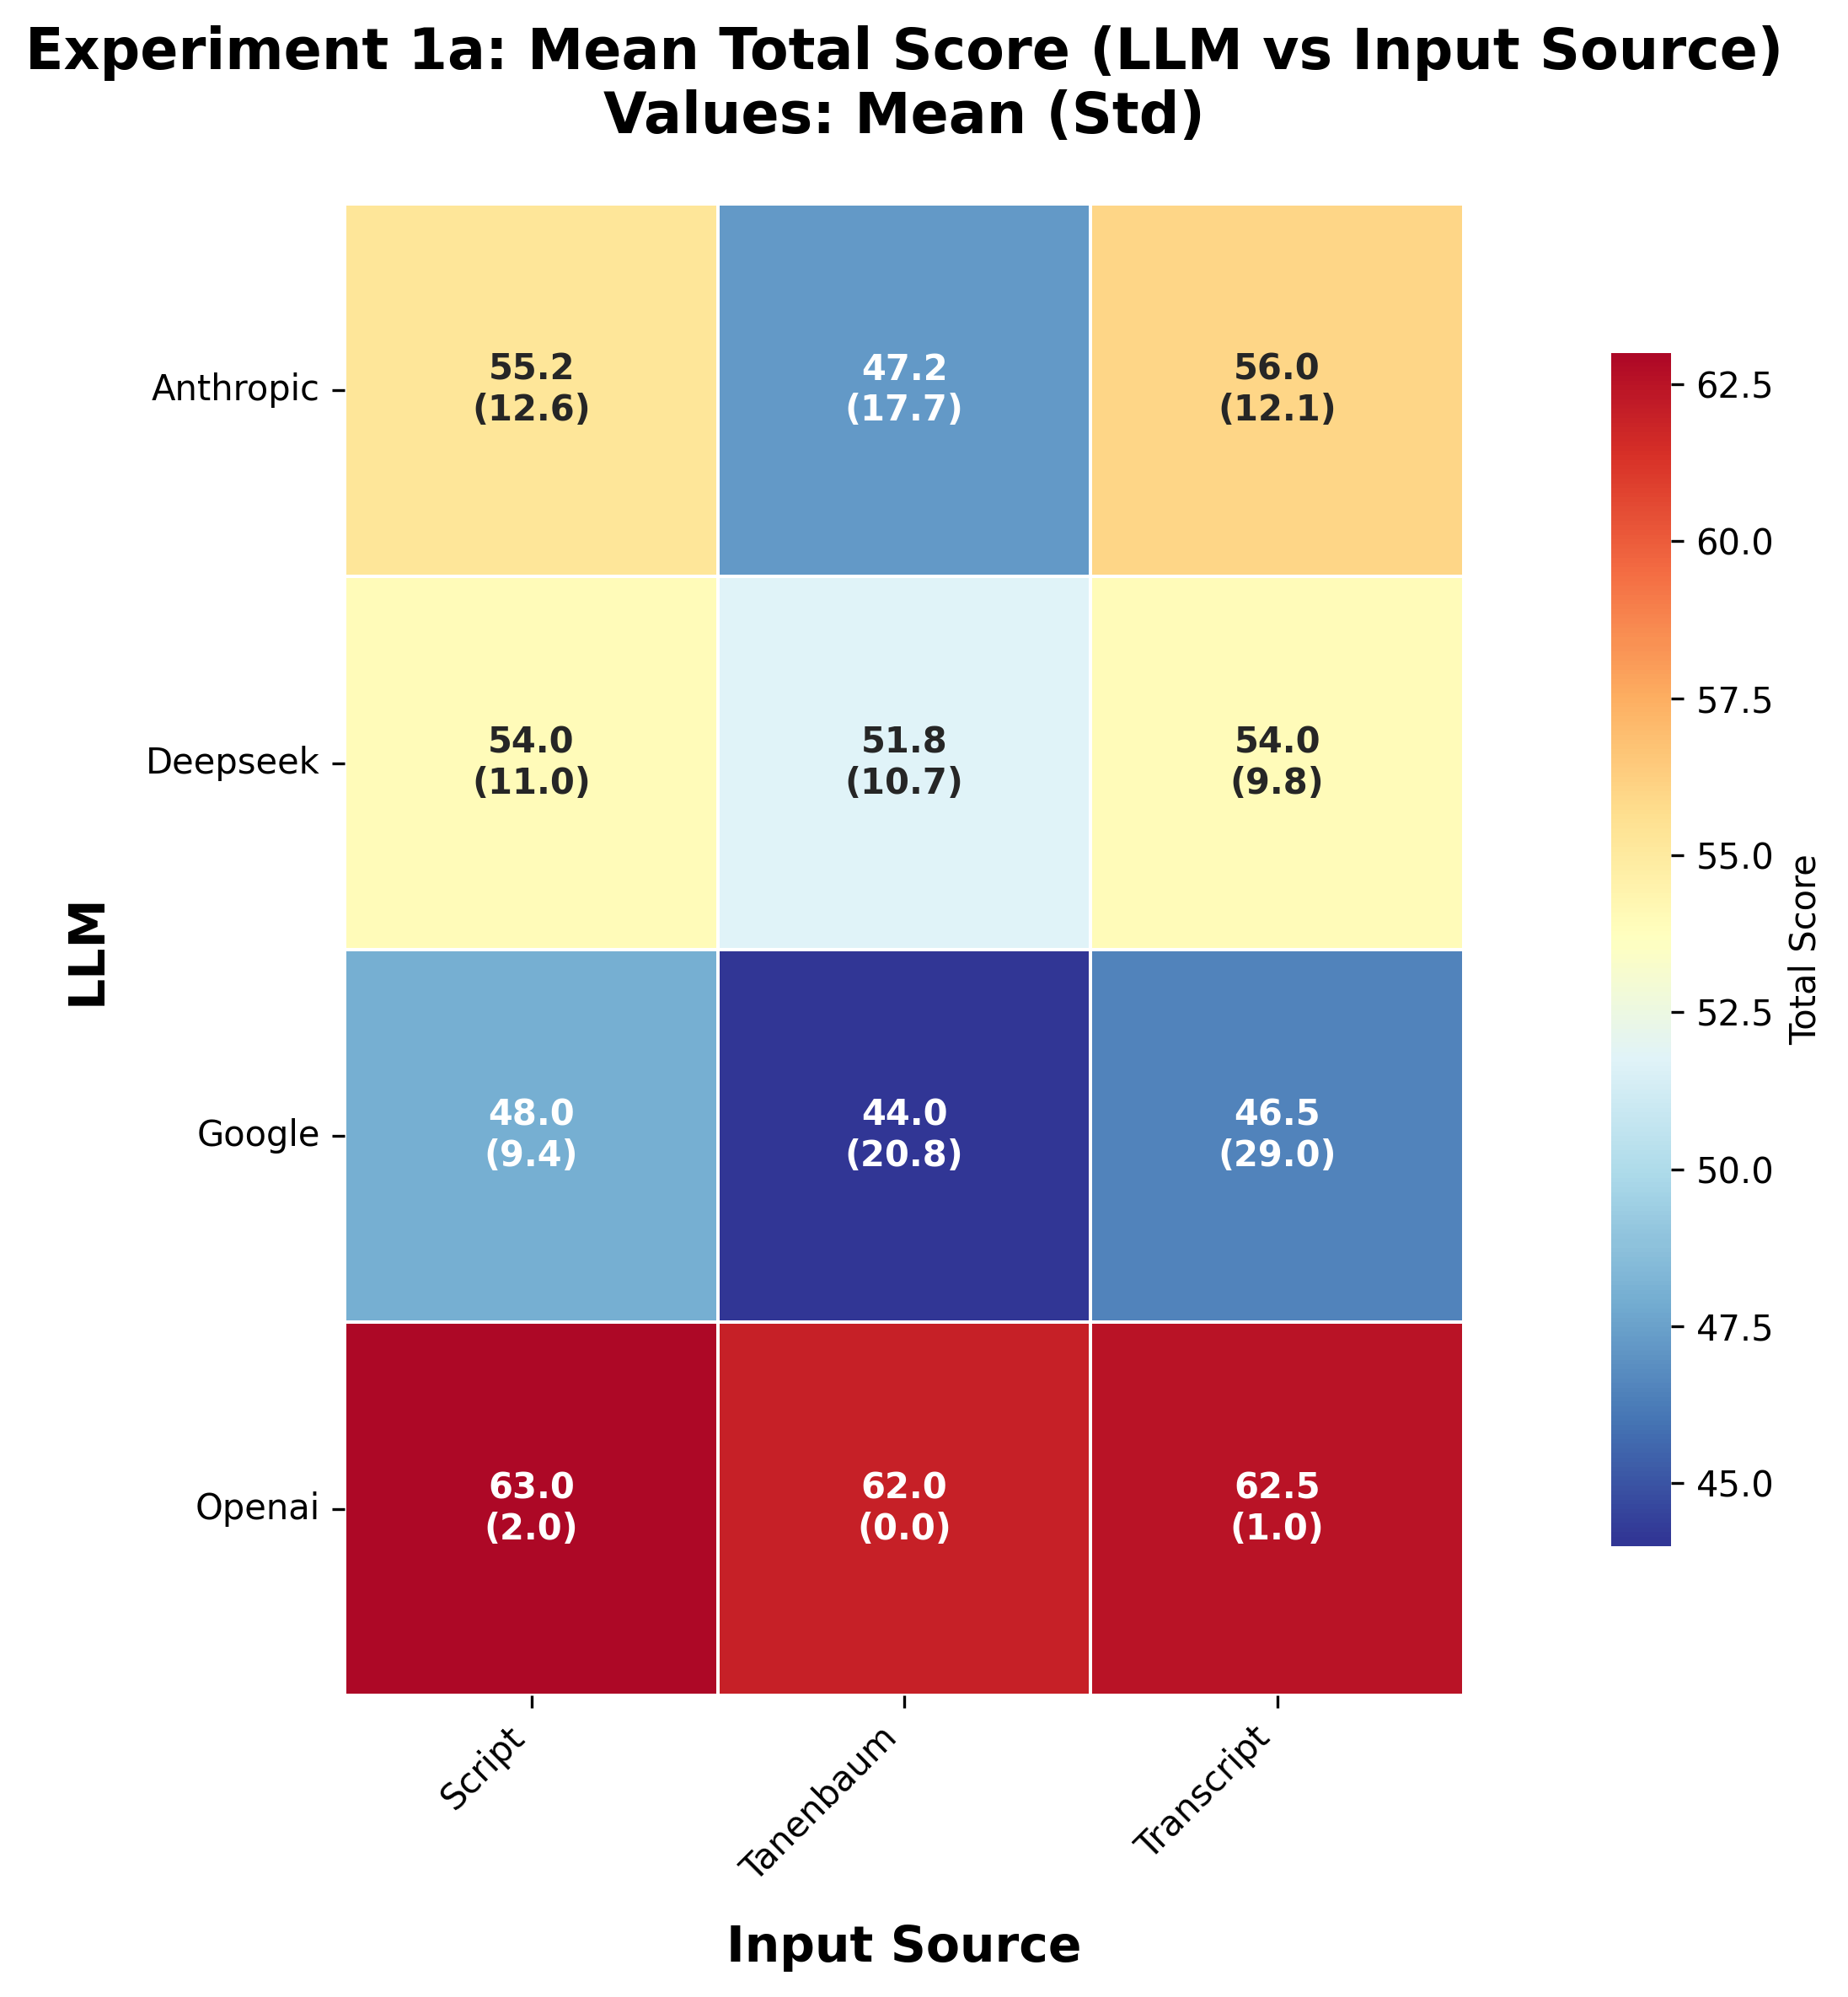


DETAILED STATISTICS - LLM vs INPUT SOURCE COMBINATIONS (EXPERIMENT 1A)

Detailed Statistics for LLM vs Input Source Combinations (Experiment 1a):


mean    std  median   min   max  count
llm       input_source                                         
anthropic script        55.25  12.58    56.5  42.0  66.0      4
          tanenbaum     47.25  17.71    51.0  25.0  62.0      4
          transcript    56.00  12.11    61.0  38.0  64.0      4
deepseek  script        54.00  10.98    56.5  39.0  64.0      4
          tanenbaum     51.75  10.72    50.5  40.0  66.0      4
          transcript    54.00   9.80    56.0  42.0  62.0      4
google    script        48.00   9.42    44.0  42.0  62.0      4
          tanenbaum     44.00  20.80    44.5  25.0  62.0      4
          transcript    46.50  29.03    60.5   3.0  62.0      4
openai    script        63.00   2.00    62.0  62.0  66.0      4
          tanenbaum     62.00   0.00    62.0  62.0  62.0      4
          transcript    62.50   1.00    62.0  62.0  64.0      4

In [176]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
plots['exp1a_source_analysis'] = fig

for i, criterion in enumerate(criteria):
    create_seaborn_boxplot(exp1a_df, 'input_source', criterion, axes[i], 
                          f'{criterion.title()}', criterion.title(), 'Input Source', scale_range=(0, 10))

create_seaborn_boxplot(exp1a_df, 'input_source', 'total_score', axes[7], 
                      'Total Score', 'Total Score', 'Input Source', scale_range=(0, 70))

plt.suptitle('Experiment 1a: Performance by Input Source', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

print("\n" + "="*80)
print("DETAILED STATISTICS - INPUT SOURCE PERFORMANCE (EXPERIMENT 1A)")
print("="*80)

exp1a_source_detailed_stats = exp1a_df.groupby('input_source')[all_criteria_with_total].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables['exp1a_source_detailed_stats'] = exp1a_source_detailed_stats
print("\nDetailed Statistics by Input Source (Experiment 1a):")
display(exp1a_source_detailed_stats)

exp1a_source_means = exp1a_df.groupby('input_source')[numeric_cols_1a].mean().round(2)
tables['exp1a_source_means'] = exp1a_source_means
print("\nMean Scores by Input Source (Experiment 1a):")
display(exp1a_source_means)

exp1a_source_overall = exp1a_df.groupby('input_source')['total_score'].mean().sort_values(ascending=False)
tables['exp1a_source_ranking'] = exp1a_source_overall
print("\nInput Source Ranking by Total Score (Experiment 1a):")
for i, (source, score) in enumerate(exp1a_source_overall.items(), 1):
    print(f"{i}. {source.title()}: {score:.2f}/70")

fig, ax = plt.subplots(figsize=(12, 8))
plots['exp1a_llm_source_heatmap'] = fig

heatmap_mean = exp1a_df.groupby(['llm', 'input_source'])['total_score'].mean().unstack()
heatmap_std = exp1a_df.groupby(['llm', 'input_source'])['total_score'].std().unstack()

annot_matrix = heatmap_mean.copy()
for i in range(len(heatmap_mean.index)):
    for j in range(len(heatmap_mean.columns)):
        mean_val = heatmap_mean.iloc[i, j]
        std_val = heatmap_std.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix.iloc[i, j] = f"{mean_val:.1f}\n({std_val:.1f})"
        elif pd.notna(mean_val):
            annot_matrix.iloc[i, j] = f"{mean_val:.1f}"

llm_labels = [label.title() for label in heatmap_mean.index]
source_labels = [label.title() for label in heatmap_mean.columns]

sns.heatmap(heatmap_mean, 
            annot=annot_matrix, 
            fmt='', 
            cmap='RdYlBu_r',
            center=heatmap_mean.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Total Score'},
            annot_kws={'size': 10, 'weight': 'bold'},
            xticklabels=source_labels, 
            yticklabels=llm_labels, 
            ax=ax)

ax.set_title('Experiment 1a: Mean Total Score (LLM vs Input Source)\nValues: Mean (Std)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Input Source', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('LLM', fontsize=14, fontweight='bold', labelpad=10)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("DETAILED STATISTICS - LLM vs INPUT SOURCE COMBINATIONS (EXPERIMENT 1A)")
print("="*80)

exp1a_llm_source_combinations = exp1a_df.groupby(['llm', 'input_source'])['total_score'].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables['exp1a_llm_source_combinations'] = exp1a_llm_source_combinations
print("\nDetailed Statistics for LLM vs Input Source Combinations (Experiment 1a):")
display(exp1a_llm_source_combinations)

## 1a.4: Analysis by Prompt Type

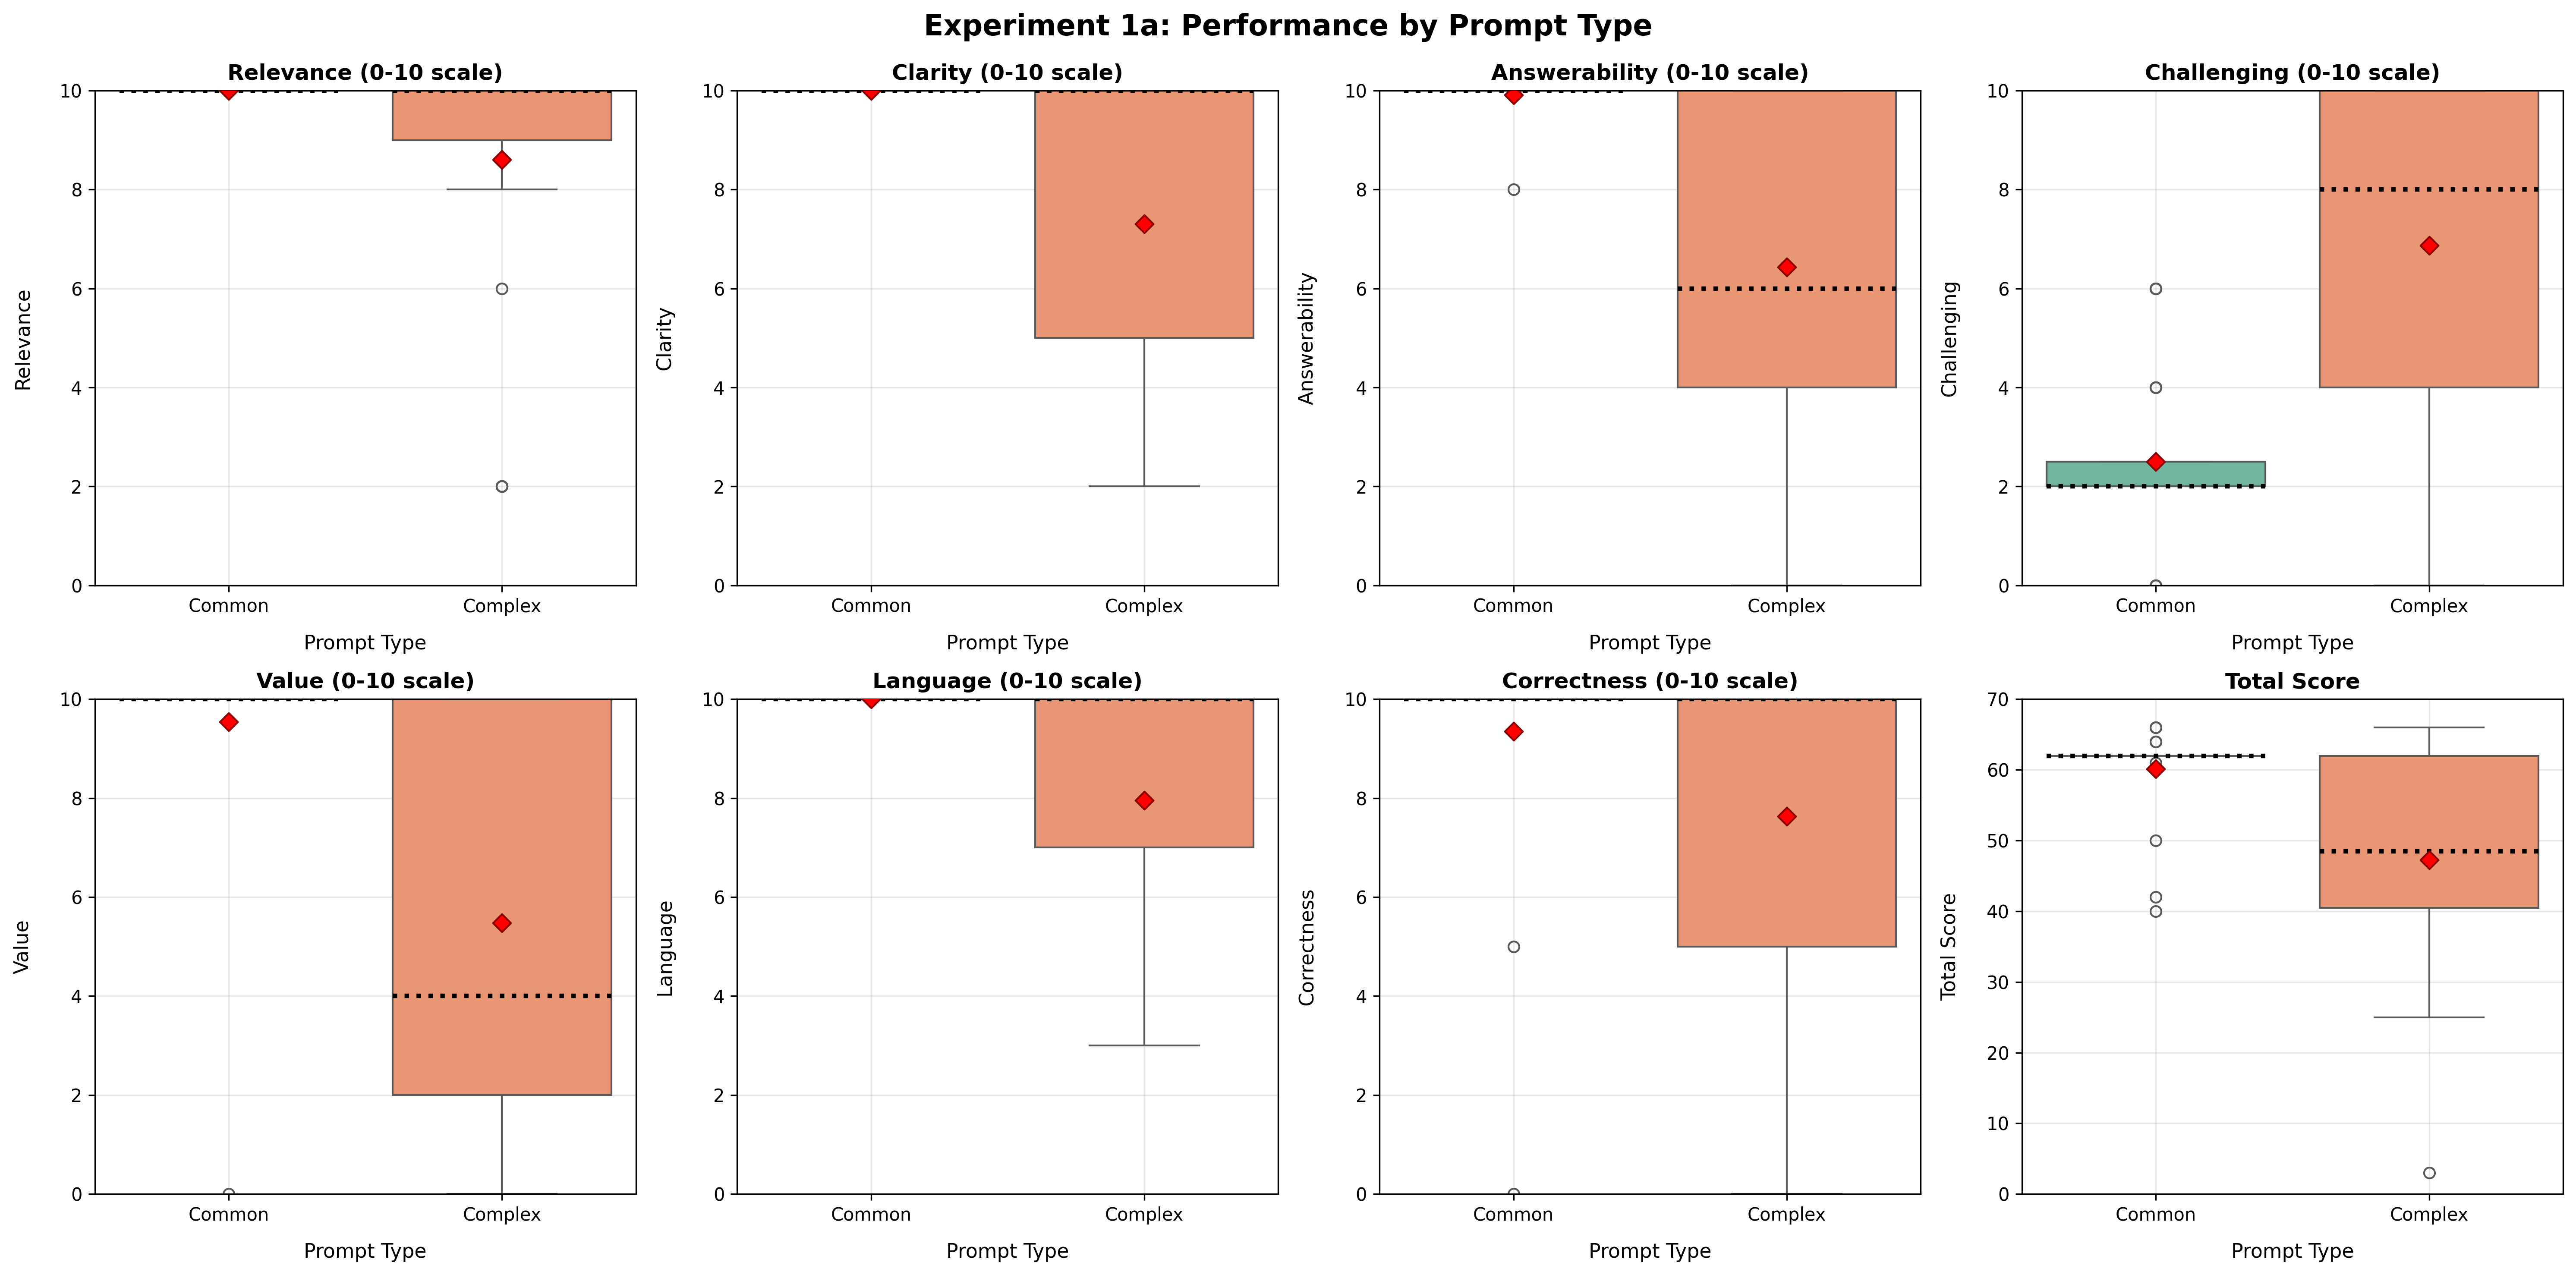


DETAILED STATISTICS - PROMPT TYPE PERFORMANCE (EXPERIMENT 1A)

Detailed Statistics by Prompt Type (Experiment 1a):


relevance                                clarity               \
                 mean   std median   min   max count    mean   std median   
prompt_type                                                                 
common          10.00  0.00   10.0  10.0  10.0    24    10.0  0.00   10.0   
complex          8.61  2.79   10.0   2.0  10.0    23     7.3  3.23   10.0   

                              answerability                                \
              min   max count          mean   std median  min   max count   
prompt_type                                                                 
common       10.0  10.0    24          9.92  0.41   10.0  8.0  10.0    24   
complex       2.0  10.0    23          6.43  3.36    6.0  0.0  10.0    23   

            challenging                               value                    \
                   mean   std median  min   max count  mean   std median  min   
prompt_type                                                                     
common             2.50  1.69    2.0  0.0   6.0    24  9.55  2.13   10.0  0.0   
complex            6.87  3.66    8.0  0.0  10.0    23  5.48  3.92    4.0  0.0   

                        language                            correctness        \
              max count     mean   std median min max count        mean   std   
prompt_type                                                                     
common       10.0    22    10.00  0.00   10.0  10  10    24        9.35  2.29   
complex      10.0    23     7.96  2.56   10.0   3  10    24        7.63  3.48   

                                    total_score                            \
            median  min   max count        mean    std median   min   max   
prompt_type                                                                 
common        10.0  0.0  10.0    23       60.12   6.56   62.0  40.0  66.0   
complex       10.0  0.0  10.0    19       47.25  15.93   48.5   3.0  66.0   

                   
            count  
prompt_type        
common         24  
complex        24


Mean Scores by Prompt Type (Experiment 1a):


,relevance,clarity,answerability,challenging,value,language,correctness
prompt_type,,,,,,,
common,10.00,10.0,9.92,2.50,9.55,10.00,9.35
complex,8.61,7.3,6.43,6.87,5.48,7.96,7.63



Complex vs Common Prompt Difference (Experiment 1a):
  Relevance: -1.39 (lower for complex)
  Clarity: -2.70 (lower for complex)
  Answerability: -3.49 (lower for complex)
  Challenging: +4.37 (higher for complex)
  Value: -4.07 (lower for complex)
  Language: -2.04 (lower for complex)
  Correctness: -1.72 (lower for complex)


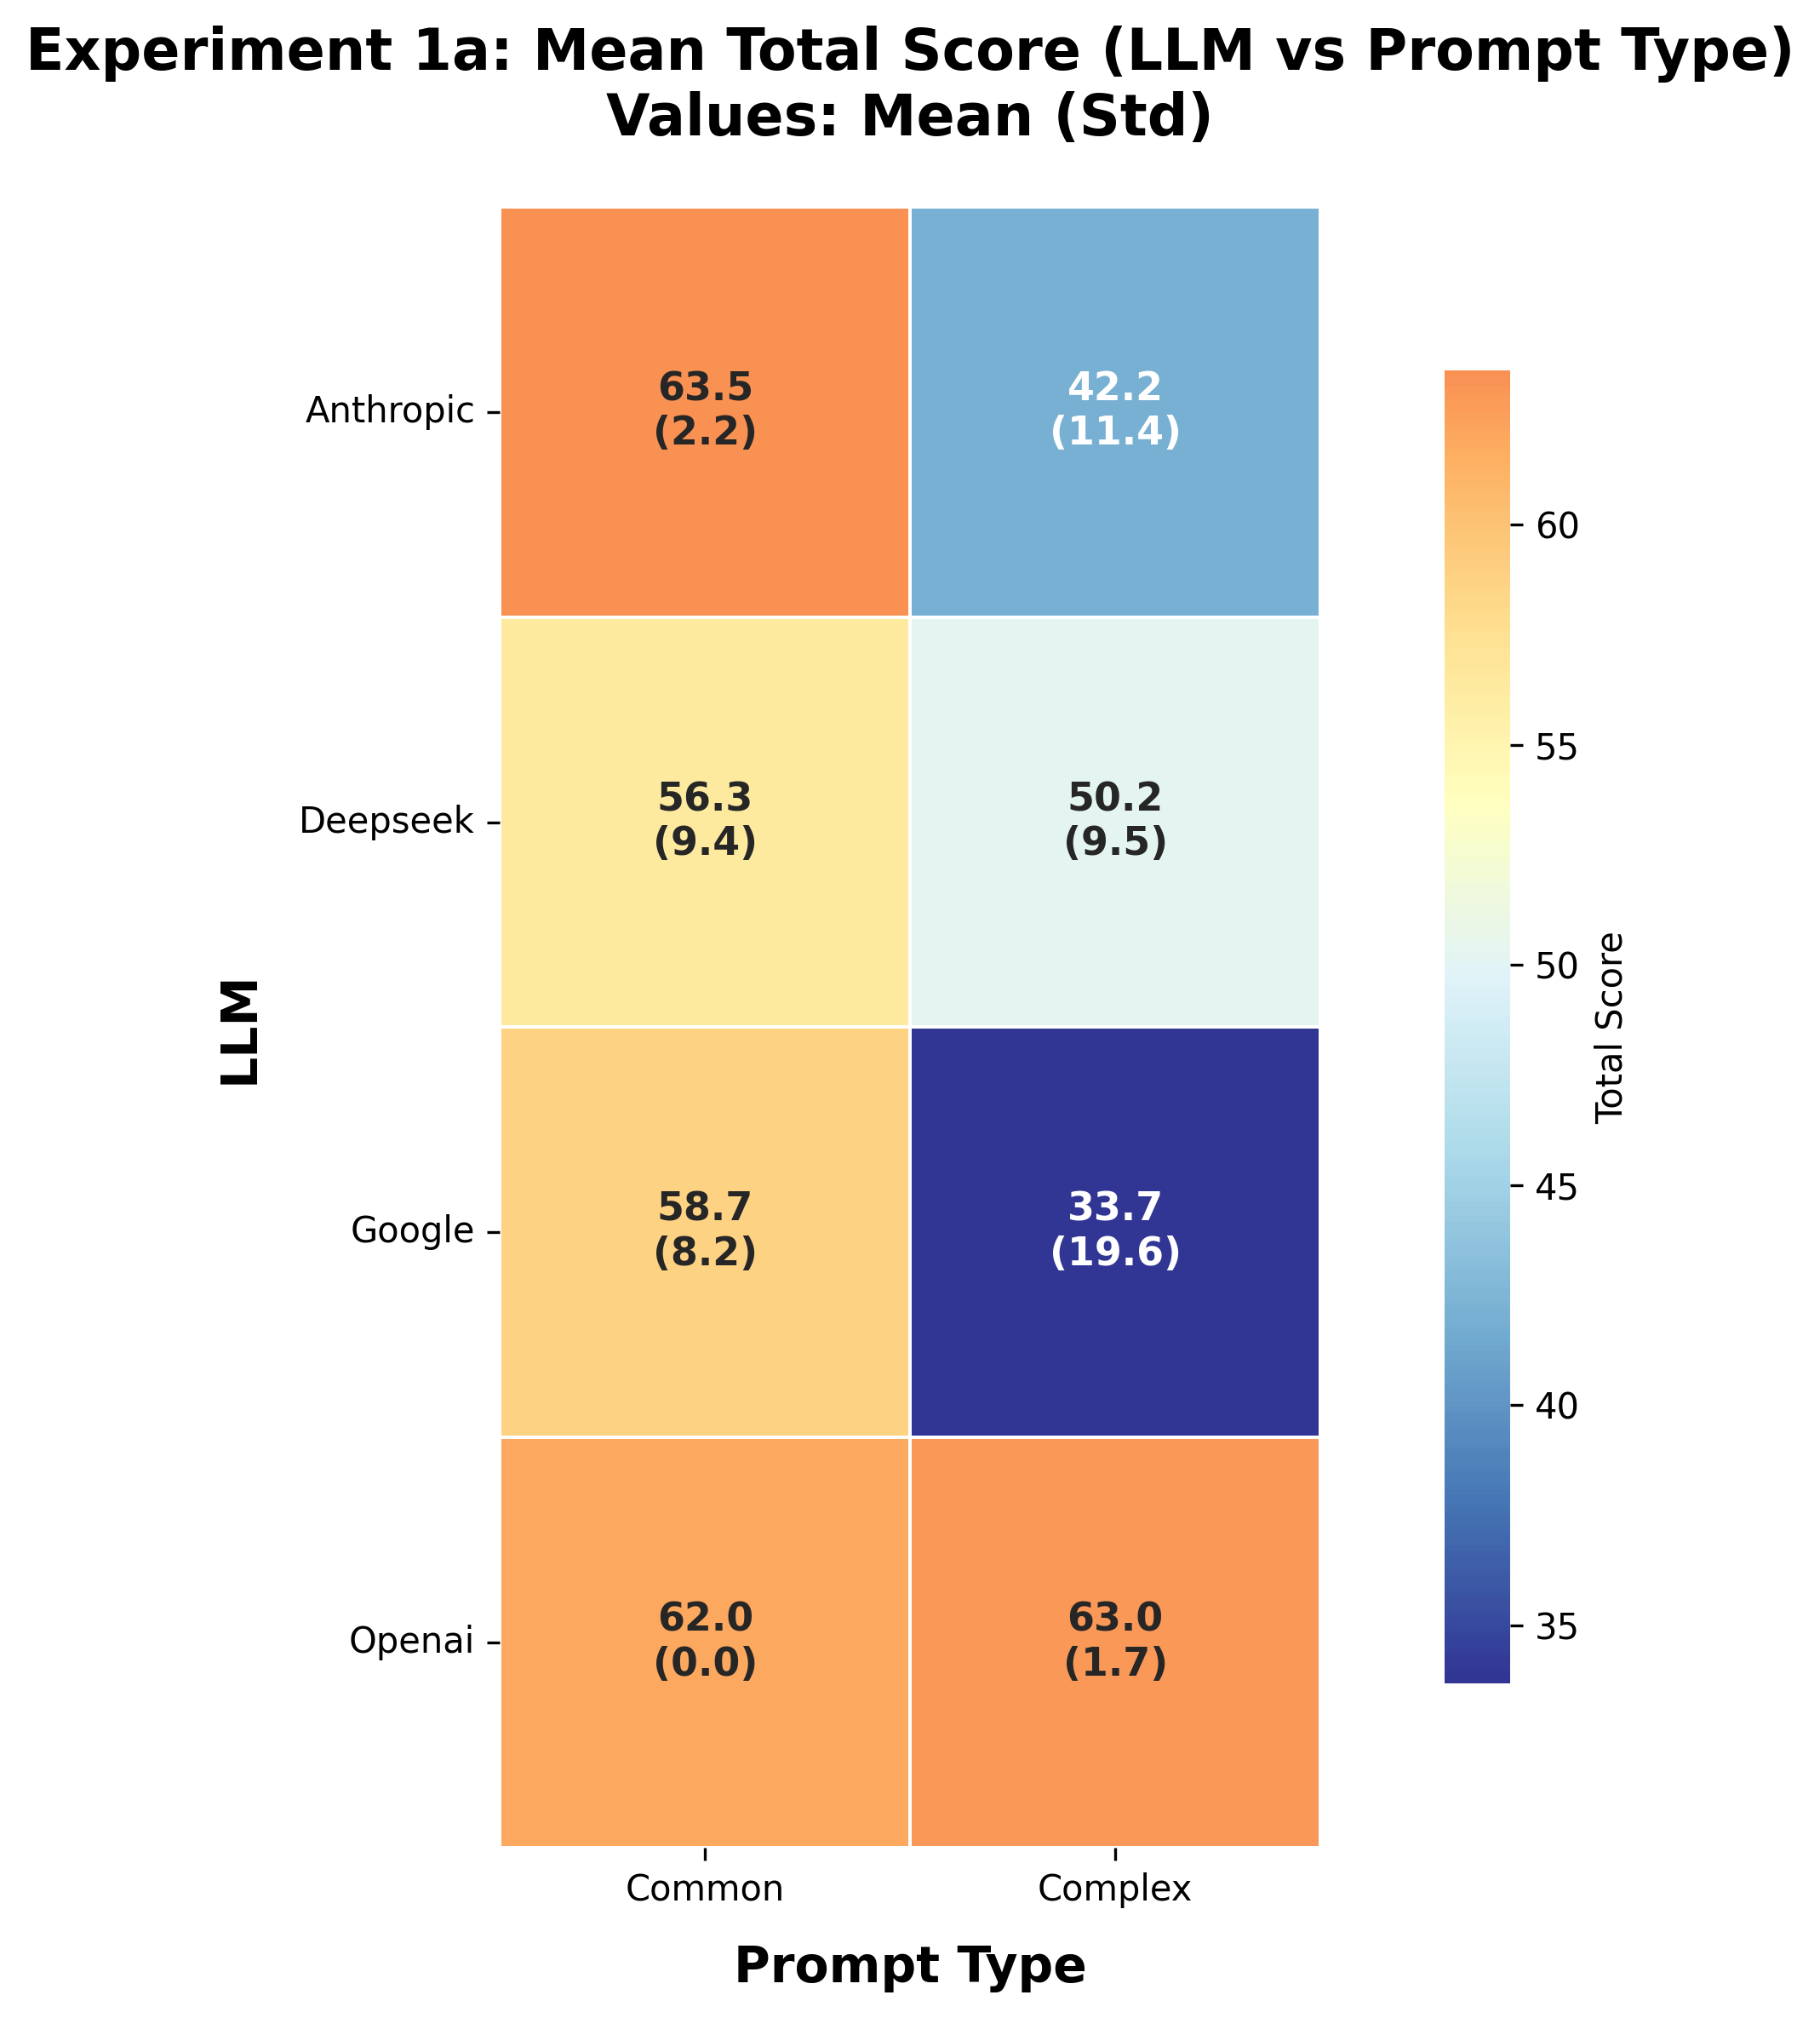


DETAILED STATISTICS - LLM vs PROMPT TYPE COMBINATIONS (EXPERIMENT 1A)

Detailed Statistics for LLM vs Prompt Type Combinations (Experiment 1a):


mean    std  median   min   max  count
llm       prompt_type                                         
anthropic common       63.50   2.17    63.0  61.0  66.0      6
          complex      42.17  11.44    41.5  25.0  60.0      6
deepseek  common       56.33   9.42    61.0  40.0  64.0      6
          complex      50.17   9.50    50.5  39.0  66.0      6
google    common       58.67   8.16    62.0  42.0  62.0      6
          complex      33.67  19.58    35.0   3.0  59.0      6
openai    common       62.00   0.00    62.0  62.0  62.0      6
          complex      63.00   1.67    62.0  62.0  66.0      6

In [177]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
plots['exp1a_prompt_analysis'] = fig

for i, criterion in enumerate(criteria):
    create_seaborn_boxplot(exp1a_df, 'prompt_type', criterion, axes[i], 
                          f'{criterion.title()}', criterion.title(), 'Prompt Type', scale_range=(0, 10))

create_seaborn_boxplot(exp1a_df, 'prompt_type', 'total_score', axes[7], 
                      'Total Score', 'Total Score', 'Prompt Type', scale_range=(0, 70))

plt.suptitle('Experiment 1a: Performance by Prompt Type', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

print("\n" + "="*80)
print("DETAILED STATISTICS - PROMPT TYPE PERFORMANCE (EXPERIMENT 1A)")
print("="*80)

exp1a_prompt_detailed_stats = exp1a_df.groupby('prompt_type')[all_criteria_with_total].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables['exp1a_prompt_detailed_stats'] = exp1a_prompt_detailed_stats
print("\nDetailed Statistics by Prompt Type (Experiment 1a):")
display(exp1a_prompt_detailed_stats)

exp1a_prompt_means = exp1a_df.groupby('prompt_type')[numeric_cols_1a].mean().round(2)
tables['exp1a_prompt_means'] = exp1a_prompt_means
print("\nMean Scores by Prompt Type (Experiment 1a):")
display(exp1a_prompt_means)

prompt_diff = exp1a_prompt_means.loc['complex'] - exp1a_prompt_means.loc['common']
print("\nComplex vs Common Prompt Difference (Experiment 1a):")
for criterion, diff in prompt_diff.items():
    direction = "higher" if diff > 0 else "lower"
    print(f"  {criterion.title()}: {diff:+.2f} ({direction} for complex)")

fig, ax = plt.subplots(figsize=(10, 8))
plots['exp1a_llm_prompt_heatmap'] = fig

heatmap_mean_prompt = exp1a_df.groupby(['llm', 'prompt_type'])['total_score'].mean().unstack()
heatmap_std_prompt = exp1a_df.groupby(['llm', 'prompt_type'])['total_score'].std().unstack()

annot_matrix_prompt = heatmap_mean_prompt.copy()
for i in range(len(heatmap_mean_prompt.index)):
    for j in range(len(heatmap_mean_prompt.columns)):
        mean_val = heatmap_mean_prompt.iloc[i, j]
        std_val = heatmap_std_prompt.iloc[i, j]
        if pd.notna(mean_val) and pd.notna(std_val):
            annot_matrix_prompt.iloc[i, j] = f"{mean_val:.1f}\n({std_val:.1f})"
        elif pd.notna(mean_val):
            annot_matrix_prompt.iloc[i, j] = f"{mean_val:.1f}"

llm_labels = [label.title() for label in heatmap_mean_prompt.index]
prompt_labels = [label.title() for label in heatmap_mean_prompt.columns]

sns.heatmap(heatmap_mean_prompt, 
            annot=annot_matrix_prompt, 
            fmt='', 
            cmap='RdYlBu_r',
            center=heatmap_mean_prompt.mean().mean(),
            square=True,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Total Score'},
            annot_kws={'size': 11, 'weight': 'bold'},
            xticklabels=prompt_labels, 
            yticklabels=llm_labels, 
            ax=ax)

ax.set_title('Experiment 1a: Mean Total Score (LLM vs Prompt Type)\nValues: Mean (Std)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Prompt Type', fontsize=14, fontweight='bold', labelpad=10)
ax.set_ylabel('LLM', fontsize=14, fontweight='bold', labelpad=10)

ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("DETAILED STATISTICS - LLM vs PROMPT TYPE COMBINATIONS (EXPERIMENT 1A)")
print("="*80)

exp1a_llm_prompt_combinations = exp1a_df.groupby(['llm', 'prompt_type'])['total_score'].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
tables['exp1a_llm_prompt_combinations'] = exp1a_llm_prompt_combinations
print("\nDetailed Statistics for LLM vs Prompt Type Combinations (Experiment 1a):")
display(exp1a_llm_prompt_combinations)

# Experiment 1b: Manipulated Content Analysis

Analysis of LLM ability to handle manipulated/incorrect content. This experiment tests whether LLMs can detect errors or incorrectly follow manipulated source material.

**Note**: Experiment 1b data may be incomplete as experts are still filling out evaluations.

In [178]:
print("EXPERIMENT 1B - DATA AVAILABILITY CHECK")
print("="*60)

exp1b_filled = exp1b_df[numeric_cols_1b].notna().sum().sum()
exp1b_total = len(exp1b_df) * len(numeric_cols_1b)

print(f"Exp 1b completion: {exp1b_filled}/{exp1b_total} ({100*exp1b_filled/exp1b_total:.1f}%)")

if exp1b_filled > 0:
    print("✓ Proceeding with Experiment 1b analysis")
    analyze_exp1b = True
else:
    print("⚠ No ratings available for Experiment 1b yet - showing structure only")
    analyze_exp1b = False
    
print(f"\nExperiment 1b structure:")
print(f"  Samples: {len(exp1b_df)}")
print(f"  LLMs: {list(exp1b_df['llm'].unique())}")
print(f"  Prompt Types: {list(exp1b_df['prompt_type'].unique())}")
print(f"  Input Sources: {list(exp1b_df['input_source'].unique())}")
print(f"  Evaluation Criteria: {numeric_cols_1b}")

print(f"\nSample Exp1b structure:")
display(exp1b_df[['input_source', 'layer', 'llm', 'prompt_type'] + numeric_cols_1b].head())

EXPERIMENT 1B - DATA AVAILABILITY CHECK
Exp 1b completion: 0/112 (0.0%)
⚠ No ratings available for Experiment 1b yet - showing structure only

Experiment 1b structure:
  Samples: 16
  LLMs: ['anthropic', 'deepseek', 'google', 'openai']
  Prompt Types: ['common', 'complex']
  Input Sources: ['script_manipulated']
  Evaluation Criteria: ['relevance', 'clarity', 'answerability', 'challenging', 'value', 'language', 'manipulation_handling']

Sample Exp1b structure:


,input_source,layer,llm,prompt_type,relevance,clarity,answerability,challenging,value,language,manipulation_handling
0,script_manipulated,2,anthropic,common,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,script_manipulated,3,anthropic,common,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,script_manipulated,4,anthropic,complex,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,script_manipulated,5,anthropic,complex,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,script_manipulated,5,deepseek,common,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [179]:
if analyze_exp1b:
    print("\nEXPERIMENT 1B - DESCRIPTIVE STATISTICS")
    print("="*60)
    
    exp1b_stats = exp1b_df[numeric_cols_1b].describe().round(2)
    tables['exp1b_overall_stats'] = exp1b_stats
    print("\nOverall Statistics (all criteria):")
    display(exp1b_stats)
    
    exp1b_llm_stats = exp1b_df.groupby('llm')[numeric_cols_1b].agg(['mean', 'std', 'count']).round(2)
    tables['exp1b_llm_stats'] = exp1b_llm_stats
    print("\nStatistics by LLM:")
    display(exp1b_llm_stats)
    
    exp1b_prompt_stats = exp1b_df.groupby('prompt_type')[numeric_cols_1b].agg(['mean', 'std', 'count']).round(2)
    tables['exp1b_prompt_stats'] = exp1b_prompt_stats
    print("\nStatistics by Prompt Type:")
    display(exp1b_prompt_stats)
    
else:
    print("\n📋 Experiment 1b analysis will be available once expert evaluations are completed.")
    print("📋 The structure is ready for analysis of manipulation handling capabilities.")


📋 Experiment 1b analysis will be available once expert evaluations are completed.
📋 The structure is ready for analysis of manipulation handling capabilities.


In [180]:
if analyze_exp1b:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    plots['exp1b_llm_analysis'] = fig
    
    criteria_1b = ['relevance', 'clarity', 'answerability', 'challenging', 'value', 'language', 'manipulation_handling']
    
    for i, criterion in enumerate(criteria_1b):
        create_seaborn_boxplot(exp1b_df, 'llm', criterion, axes[i], 
                              f'{criterion.title()}', criterion.title(), 'LLM', scale_range=(0, 10))
    
    create_seaborn_boxplot(exp1b_df, 'llm', 'total_score', axes[7], 
                          'Total Score', 'Total Score', 'LLM', scale_range=(0, 70))
    
    plt.suptitle('Experiment 1b: LLM Performance (Manipulation Handling)', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    
    print("\n" + "="*80)
    print("DETAILED STATISTICS - LLM PERFORMANCE (EXPERIMENT 1B)")
    print("="*80)
    
    all_criteria_1b_with_total = criteria_1b + ['total_score']
    exp1b_llm_detailed_stats = exp1b_df.groupby('llm')[all_criteria_1b_with_total].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
    tables['exp1b_llm_detailed_stats'] = exp1b_llm_detailed_stats
    print("\nDetailed Statistics by LLM (Experiment 1b):")
    display(exp1b_llm_detailed_stats)
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    plots['exp1b_prompt_analysis'] = fig
    
    for i, criterion in enumerate(criteria_1b):
        create_seaborn_boxplot(exp1b_df, 'prompt_type', criterion, axes[i], 
                              f'{criterion.title()}', criterion.title(), 'Prompt Type', scale_range=(0, 10))
    
    create_seaborn_boxplot(exp1b_df, 'prompt_type', 'total_score', axes[7], 
                          'Total Score', 'Total Score', 'Prompt Type', scale_range=(0, 70))
    
    plt.suptitle('Experiment 1b: Performance by Prompt Type (Manipulation Handling)', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    
    print("\n" + "="*80)
    print("DETAILED STATISTICS - PROMPT TYPE PERFORMANCE (EXPERIMENT 1B)")
    print("="*80)
    
    exp1b_prompt_detailed_stats = exp1b_df.groupby('prompt_type')[all_criteria_1b_with_total].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
    tables['exp1b_prompt_detailed_stats'] = exp1b_prompt_detailed_stats
    print("\nDetailed Statistics by Prompt Type (Experiment 1b):")
    display(exp1b_prompt_detailed_stats)
    
    exp1b_llm_means = exp1b_df.groupby('llm')[numeric_cols_1b].mean().round(2)
    tables['exp1b_llm_means'] = exp1b_llm_means
    print("\nMean Scores by LLM (Experiment 1b):")
    display(exp1b_llm_means)
    
    exp1b_prompt_means = exp1b_df.groupby('prompt_type')[numeric_cols_1b].mean().round(2)
    tables['exp1b_prompt_means'] = exp1b_prompt_means
    print("\nMean Scores by Prompt Type (Experiment 1b):")
    display(exp1b_prompt_means)
    
else:
    print("📊 Visualization section ready for Experiment 1b data")
    print("📊 Will include: LLM analysis, Prompt type comparison, Manipulation handling focus")

📊 Visualization section ready for Experiment 1b data
📊 Will include: LLM analysis, Prompt type comparison, Manipulation handling focus


# Cross-Experiment Comparison

Comparison between Experiment 1a (original content) and Experiment 1b (manipulated content) to understand LLM behavior differences.

In [181]:
if analyze_exp1b:
    common_criteria = ['relevance', 'clarity', 'answerability', 'challenging', 'value', 'language']
    
    exp1a_comp = exp1a_df[['experiment', 'llm', 'prompt_type'] + common_criteria].copy()
    exp1b_comp = exp1b_df[['experiment', 'llm', 'prompt_type'] + common_criteria].copy()
    combined_df = pd.concat([exp1a_comp, exp1b_comp], ignore_index=True)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    plots['cross_experiment_llm'] = fig
    
    for i, criterion in enumerate(common_criteria):
        create_seaborn_boxplot(combined_df, 'experiment', criterion, axes[i], 
                              f'{criterion.title()} (1a vs 1b)', criterion.title(), 'Experiment', scale_range=(0, 10))
    
    plt.suptitle('Cross-Experiment Comparison: 1a (Original) vs 1b (Manipulated)', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    
    print("\n" + "="*80)
    print("DETAILED STATISTICS - CROSS-EXPERIMENT COMPARISON")
    print("="*80)
    
    cross_experiment_detailed_stats = combined_df.groupby('experiment')[common_criteria].agg(['mean', 'std', 'median', 'min', 'max', 'count']).round(2)
    tables['cross_experiment_detailed_stats'] = cross_experiment_detailed_stats
    print("\nDetailed Cross-Experiment Statistics Comparison:")
    display(cross_experiment_detailed_stats)
    
    comparison_stats = combined_df.groupby('experiment')[common_criteria].agg(['mean', 'std']).round(2)
    tables['cross_experiment_stats'] = comparison_stats
    print("\nCross-Experiment Statistics Comparison:")
    display(comparison_stats)
    
    exp1a_means = combined_df[combined_df['experiment'] == 'exp1a'][common_criteria].mean()
    exp1b_means = combined_df[combined_df['experiment'] == 'exp1b'][common_criteria].mean()
    performance_diff = exp1a_means - exp1b_means
    
    print("\nPerformance Difference (1a - 1b):")
    for criterion, diff in performance_diff.items():
        direction = "better in 1a" if diff > 0 else "better in 1b"
        print(f"  {criterion.title()}: {diff:+.2f} ({direction})")
    
else:
    print("🔄 Cross-experiment comparison will be available once Experiment 1b data is complete.")
    print("🔄 Will compare: Content adherence, Question quality, Error handling capabilities")

🔄 Cross-experiment comparison will be available once Experiment 1b data is complete.
🔄 Will compare: Content adherence, Question quality, Error handling capabilities


# Summary and Key Insights

This section provides a comprehensive summary of findings from the qualitative analysis of Experiment 1.

In [182]:
print("EXPERIMENT 1 - KEY INSIGHTS")
print("="*50)

print("\n🔍 EXPERIMENT 1A INSIGHTS:")
print("-" * 30)

best_llm = exp1a_llm_overall.index[0]
best_score = exp1a_llm_overall.iloc[0]
print(f"✓ Best LLM: {best_llm.title()} (avg score: {best_score:.2f})")

best_source = exp1a_source_overall.index[0]
best_source_score = exp1a_source_overall.iloc[0]
print(f"✓ Best Input Source: {best_source.title()} (avg score: {best_source_score:.2f})")

complex_avg = exp1a_prompt_means.loc['complex'].mean()
common_avg = exp1a_prompt_means.loc['common'].mean()
prompt_winner = "Complex" if complex_avg > common_avg else "Common"
print(f"✓ Better Prompt Type: {prompt_winner} ({complex_avg:.2f} vs {common_avg:.2f})")

print(f"\n📊 CRITERIA PERFORMANCE (EXP 1A):")
criteria_avg = exp1a_df[numeric_cols_1a].mean().sort_values(ascending=False)
for criterion, score in criteria_avg.items():
    print(f"  {criterion.title()}: {score:.2f}")

low_performance = criteria_avg[criteria_avg < 7.0]
if len(low_performance) > 0:
    print(f"\n⚠ Areas needing improvement (< 7.0):")
    for criterion, score in low_performance.items():
        print(f"  {criterion.title()}: {score:.2f}")

if analyze_exp1b:
    print(f"\n🔍 EXPERIMENT 1B INSIGHTS:")
    print("-" * 30)
    
    exp1b_llm_overall = exp1b_df.groupby('llm')[numeric_cols_1b].mean().mean(axis=1).sort_values(ascending=False)
    best_llm_1b = exp1b_llm_overall.index[0]
    best_score_1b = exp1b_llm_overall.iloc[0]
    print(f"✓ Best LLM for Manipulation: {best_llm_1b.title()} (avg score: {best_score_1b:.2f})")
    
    manip_scores = exp1b_df.groupby('llm')['manipulation_handling'].mean().sort_values(ascending=False)
    print(f"✓ Manipulation Handling Leader: {manip_scores.index[0].title()} ({manip_scores.iloc[0]:.2f})")
    
else:
    print(f"\n📋 EXPERIMENT 1B: Awaiting expert evaluations")
    print("   Will analyze manipulation handling capabilities")

print(f"\n📈 OVERALL RECOMMENDATIONS:")
print("-" * 30)
print(f"• Focus on {best_llm.title()} for best overall performance")
print(f"• {best_source.title()} source material produces highest quality questions")
print(f"• {prompt_winner} prompts show better results")
if len(low_performance) > 0:
    print(f"• Improve {', '.join(low_performance.index)} criteria")
print(f"• Continue monitoring manipulation handling capabilities in 1b")

EXPERIMENT 1 - KEY INSIGHTS

🔍 EXPERIMENT 1A INSIGHTS:
------------------------------
✓ Best LLM: Openai (avg score: 8.93)
✓ Best Input Source: Script (avg score: 55.06)
✓ Better Prompt Type: Common (7.18 vs 8.76)

📊 CRITERIA PERFORMANCE (EXP 1A):
  Relevance: 9.32
  Language: 8.98
  Clarity: 8.68
  Correctness: 8.57
  Answerability: 8.21
  Value: 7.47
  Challenging: 4.64

⚠ Areas needing improvement (< 7.0):
  Challenging: 4.64

📋 EXPERIMENT 1B: Awaiting expert evaluations
   Will analyze manipulation handling capabilities

📈 OVERALL RECOMMENDATIONS:
------------------------------
• Focus on Openai for best overall performance
• Script source material produces highest quality questions
• Common prompts show better results
• Improve challenging criteria
• Continue monitoring manipulation handling capabilities in 1b


## Data Export

Save all tables and plots for use in thesis and presentations.

In [ ]:
def save_all_results():
    print("💾 Saving results...")
    
    # Save tables
    tables_saved = 0
    for table_name, table_data in tables.items():
        try:
            csv_path = os.path.join(output_tables_path, f"{table_name}.csv")
            table_data.to_csv(csv_path)
            tables_saved += 1
            print(f"✓ Saved table: {table_name}.csv")
        except Exception as e:
            print(f"✗ Error saving {table_name}: {e}")
    
    # Save plots
    plots_saved = 0
    for plot_name, plot_fig in plots.items():
        try:
            png_path = os.path.join(output_plots_path, f"{plot_name}.png")
            plot_fig.savefig(png_path, dpi=300, bbox_inches='tight')
            plots_saved += 1
            print(f"✓ Saved plot: {plot_name}.png")
        except Exception as e:
            print(f"✗ Error saving {plot_name}: {e}")
    
    print(f"\n📊 Export Summary:")
    print(f"  Tables saved: {tables_saved}")
    print(f"  Plots saved: {plots_saved}")
    print(f"  Output location: {output_base_path}")
    
    # Create summary report
    # summary_path = os.path.join(output_base_path, "analysis_summary.txt")
    # with open(summary_path, 'w') as f:
    #     f.write("EXPERIMENT 1 QUALITATIVE ANALYSIS SUMMARY\n")
    #     f.write("=" * 50 + "\n\n")
        
    #     f.write("DATA SOURCES:\n")
    #     f.write(f"- Expert 1 Exp1a: {len(exp1a_df)} samples\n")
    #     f.write(f"- Expert 1 Exp1b: {len(exp1b_df)} samples\n")
    #     f.write(f"- Analysis complete: {analyze_exp1b}\n\n")
        
    #     f.write("KEY FINDINGS:\n")
    #     f.write(f"- Best LLM (1a): {exp1a_llm_overall.index[0].title()}\n")
    #     f.write(f"- Best Input Source (1a): {exp1a_source_overall.index[0].title()}\n")
    #     f.write(f"- Prompt preference: {'Complex' if complex_avg > common_avg else 'Common'}\n\n")
        
    #     f.write("OUTPUTS:\n")
    #     f.write(f"- Tables: {tables_saved}\n")
    #     f.write(f"- Plots: {plots_saved}\n")
    #     f.write(f"- Location: {output_base_path}\n")
    
    # print(f"✓ Analysis summary saved: analysis_summary.txt")

# Execute the save function
save_all_results()

💾 Saving results...
✓ Saved table: exp1a_overall_stats.csv
✓ Saved table: exp1a_llm_stats.csv
✓ Saved table: exp1a_source_stats.csv
✓ Saved table: exp1a_prompt_stats.csv
✓ Saved table: exp1a_llm_detailed_stats.csv
✓ Saved table: exp1a_llm_means.csv
✓ Saved table: exp1a_llm_ranking.csv
✓ Saved table: exp1a_source_detailed_stats.csv
✓ Saved table: exp1a_source_means.csv
✓ Saved table: exp1a_source_ranking.csv
✓ Saved table: exp1a_llm_source_combinations.csv
✓ Saved table: exp1a_prompt_detailed_stats.csv
✓ Saved table: exp1a_prompt_means.csv
✓ Saved table: exp1a_llm_prompt_combinations.csv
✓ Saved plot: exp1a_llm_analysis.png
✓ Saved plot: exp1a_llm_analysis.png
✓ Saved plot: exp1a_source_analysis.png
✓ Saved plot: exp1a_source_analysis.png
✓ Saved plot: exp1a_llm_source_heatmap.png
✓ Saved plot: exp1a_llm_source_heatmap.png
✓ Saved plot: exp1a_prompt_analysis.png
✓ Saved plot: exp1a_llm_prompt_heatmap.png

📊 Export Summary:
  Tables saved: 14
  Plots saved: 5
  Output location: /home/mal